<a href="https://colab.research.google.com/github/cshenoy86/machinelearning/blob/01-iris-classification/iris_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Iris Flower Classification**

This project uses the Iris dataset to train a simple machine learning model that can classify iris flowers into three species: Setosa, Versicolor, and Virginica.

We will use


*   pandas for data handling
*   matplotlib and seaborn for data visualization
*   scikit learn for building and evaluating the model






**1. Import Libraries**

In [ ]:
#Import the required libraries
# Pandas is used for data handling
# Matplotlib and Seaborn will be used for data visualization, to create graphs and charts
# Scikit learn will be used for machine learning

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

**2. Load and Explore Dataset**

In [ ]:
#Load the built in iris data set from sklearn
iris = load_iris()

#Create a dataframe from the data
df = pd.DataFrame(data = iris.data,columns = iris.feature_names)

#Check if data is uploaded properly
print("Data shape:",iris.data.shape)
print("Feature Names:",iris.feature_names)

#Add the species (target labels) to the data frame
df['species'] = iris.target

#Print the first 5 rows of data
df.head()
df.tail()

### ⚠️ Common Pitfall

If you try:
```python
pd.DataFrame(data=iris, columns=iris.feature_names)

you will get NaN values because iris is not the actual data table.
You should use iris.data, which is a NumPy array of shape (150, 4).


**3. Visualize the Data**



In [ ]:
#Plot pairplots to see the relationshio between features
# Use hue to specify colours. This will show the different species in different colours, so use that variable

sns.pairplot(df,hue= 'species')

**4. Split the Data into Train and Test Sets**

In [ ]:
#Split the dataset into features and target
X = df[iris.feature_names] #all columns with measurements
y = df['species'] #column that contains the target label,specifies which species

In [ ]:
#Split the data such that 80% is used for training and 20% for test
#random state is set so that results are reproducible
# train_test_split separates the data into training and testing sets
# test_size=0.2 means 20% of data is for testing, 80% for training
# random_state is like a seed — it makes sure the split is always the same


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**5. Train the Model**

1. We're creating an object of the LogisticRegression class from sklearn.linear_model.

   

*   model = LogisticRegression(max_iter=200)
*   max_iter=200 means the algorithm can go through the  data up to 200 times to adjust and find the best weights for making accurate predictions.
*   Internally, this model will:Learn how each feature (sepal length, petal width, etc.) contributes to predicting the species.
*   Assign weights to each feature for each possible class (Setosa, Versicolor, Virginica).
*    Use a mathematical function (sigmoid or softmax for multi-class) to make predictions.


2. This is where the learning actually happens.
  model.fit(X_train, y_train)

*   X_train contains the input features (sepal/petal length & width).
*   y_train contains the correct labels (species: 0 =  Setosa, 1 = Versicolor, 2 = Virginica).
*   The model goes through the training data and adjusts weights to learn how to classify flowers based on patterns.









  


In [ ]:
#Create a Logistic Regression Model
# We create a LogisticRegression model object
# max_iter=200 ensures the model has enough iterations to converge

model = LogisticRegression(max_iter=200)

# model.fit(...) trains the model using X_train and y_train
# The model learns which combinations of features point to which species.
# For example, short petals might often mean "Setosa", while longer ones mean "Virginica".
model.fit(X_train, y_train)


LogisticRegression(max_iter=200)

**6. Predict & Evaluate the Model’s Accuracy**


*   model.predict(X_test) uses the trained model to predict species for unseen flowers
*   y_pred contains the predicted labels (e.g., 0, 1, 2)
*   accuracy_score compares predicted vs actual labels and tells us what % were correct
*   classification_report gives precision, recall, and F1-score for each class:
*   Precision: Of the ones predicted as Setosa, how many were actually Setosa?
*  Recall: Of all actual Setosas, how many did we correctly identify?
*   F1-score: A balance between precision and recall

In [ ]:
#Use the trained model to make prediction on the test set
y_pred = model.predict(X_test)

#Check how accurate the predictions are
print("Accuracy Score:",accuracy_score(y_test,y_pred))

#Print a detailed report
print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

Accuracy Score: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**7. Visualize the Confusion Matrix**

A confusion matrix gives you a clear picture of how well your model is performing — it shows where it’s getting confused between classes.

Confusion_matrix compares actual vs predicted labels and shows the counts
For example, how many actual Setosa flowers were predicted as Setosa, etc.

ConfusionMatrixDisplay makes a nice visual chart of this matrix.

Each cell shows how many flowers of a true class were predicted as another class

Perfect prediction means values only on the diagonal


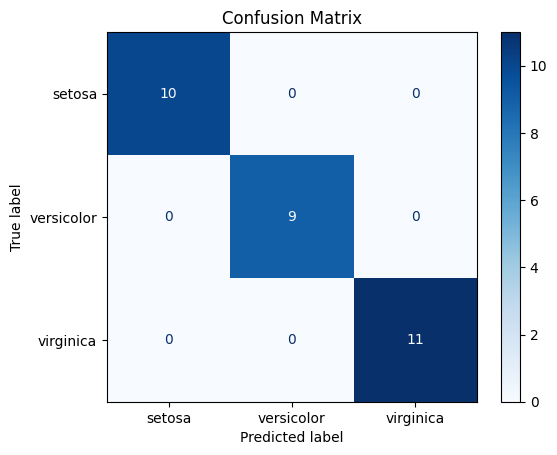

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix as a visual
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
